In [5]:
import json
import numpy as np

with open("all_objects_data.json", "r") as f:
    data = json.load(f)

print(f"Total objects loaded: {len(data)}")

Total objects loaded: 100


In [7]:
# example bin definitions
density_bins = [0, 200, 400, 600, 800, 1000]
E_bins = [1e6, 1e7, 1e8, 1e9]
nu_bins = [0, 0.1, 0.2, 0.3, 0.4]


# helpers
def midpoint(obj, key):
    r = obj["material"][key]
    return (r["min"] + r["max"]) / 2


def bin_index(value, bins):
    return np.digitize([value], bins)[0] - 1


# init
dist = {
    "density": [0] * (len(density_bins) - 1),
    "youngs_modulus": [0] * (len(E_bins) - 1),
    "poisson_ratio": [0] * (len(nu_bins) - 1),
}

# process each object
for obj in data.values():
    d = midpoint(obj, "density_kg_per_m3")
    E = midpoint(obj, "youngs_modulus_pa")
    nu = midpoint(obj, "poisson_ratio")

    di = bin_index(d, density_bins)
    Ei = bin_index(E, E_bins)
    nui = bin_index(nu, nu_bins)

    if 0 <= di < len(dist["density"]):
        dist["density"][di] += 1
    if 0 <= Ei < len(dist["youngs_modulus"]):
        dist["youngs_modulus"][Ei] += 1
    if 0 <= nui < len(dist["poisson_ratio"]):
        dist["poisson_ratio"][nui] += 1

print(dist)

{'density': [53, 27, 6, 9, 1], 'youngs_modulus': [19, 33, 31], 'poisson_ratio': [0, 6, 38, 47]}


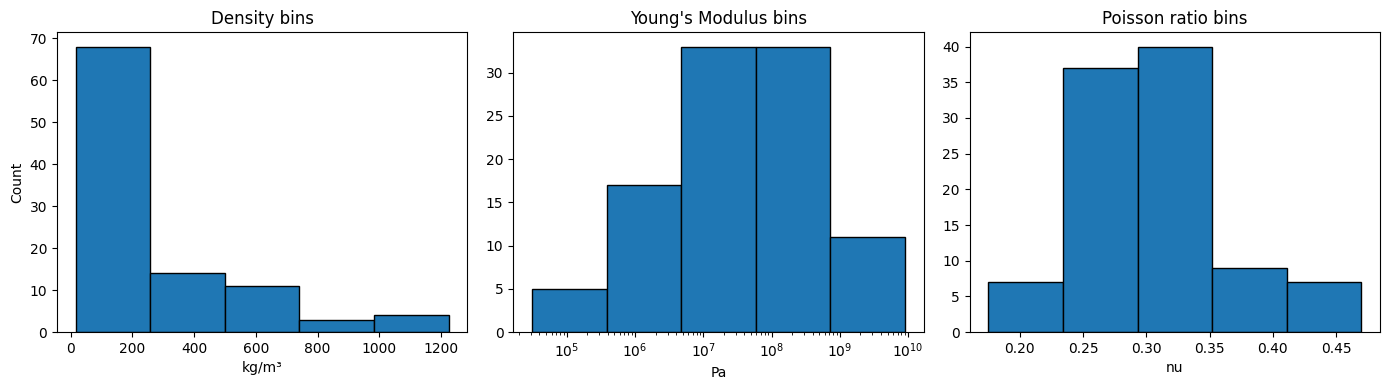

In [9]:
import json
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load your JSON file
# ---------------------------------------------------
with open("all_objects_data.json", "r") as f:
    data = json.load(f)

# ---------------------------------------------------
# Extract midpoint values for each object
# ---------------------------------------------------
density_vals = []
E_vals = []
nu_vals = []

for obj in data.values():
    mat = obj["material"]

    d = (mat["density_kg_per_m3"]["min"] + mat["density_kg_per_m3"]["max"]) * 0.5
    E = (mat["youngs_modulus_pa"]["min"] + mat["youngs_modulus_pa"]["max"]) * 0.5
    nu = (mat["poisson_ratio"]["min"] + mat["poisson_ratio"]["max"]) * 0.5

    density_vals.append(d)
    E_vals.append(E)
    nu_vals.append(nu)

density_vals = np.array(density_vals)
E_vals = np.array(E_vals)
nu_vals = np.array(nu_vals)

# ---------------------------------------------------
# Choose sensible automatic bins
# ---------------------------------------------------
density_bins = np.linspace(density_vals.min(), density_vals.max(), 6)
E_bins = np.logspace(np.log10(E_vals.min()), np.log10(E_vals.max()), 6)
nu_bins = np.linspace(nu_vals.min(), nu_vals.max(), 6)

# ---------------------------------------------------
# Plot the distributions
# ---------------------------------------------------
plt.figure(figsize=(14, 4))

# Density
plt.subplot(1, 3, 1)
plt.hist(density_vals, bins=density_bins, edgecolor="black")
plt.title("Density bins")
plt.xlabel("kg/m³")
plt.ylabel("Count")

# Young's modulus (log scale)
plt.subplot(1, 3, 2)
plt.hist(E_vals, bins=E_bins, edgecolor="black")
plt.xscale("log")
plt.title("Young's Modulus bins")
plt.xlabel("Pa")

# Poisson ratio
plt.subplot(1, 3, 3)
plt.hist(nu_vals, bins=nu_bins, edgecolor="black")
plt.title("Poisson ratio bins")
plt.xlabel("nu")

plt.tight_layout()
plt.show()